In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PriceSim import stock_full
from greeks import CallDelta, CallOption

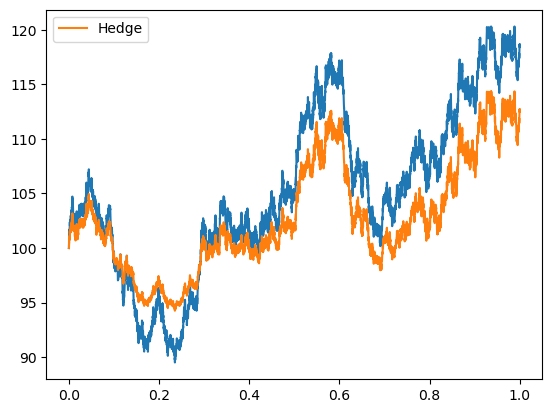

In [16]:
#First simulation of delta hedge

T = 10000
Vol = 0.2
S_0 = 100
strike = 100
r = 0.05
shares = 1

dt = 1/T
t_arr = np.linspace(0,1,T+1)
mat = 1


#Stock price
stock_price = stock_full(100,0.05,Vol,dt,1)



# Hedge
Delta = np.zeros(T+1)
stock_position = np.zeros(T+1)
cash = np.zeros(T+1)
value = np.zeros(T+1)

initial_capital = 100

for j in range(T+1):

    t = j*dt
    S = stock_price[j]

    Delta[j] = CallDelta(S, Vol, 0, r, strike, mat-t)

    if j == 0:
        # buy Delta shares using the initial capital
        stock_position[j] = Delta[j]
        cash[j] = initial_capital - Delta[j]*S

    else:
        # rebalance stock position
        dShares = Delta[j] - Delta[j-1]

        stock_position[j] = stock_position[j-1] + dShares

        # pay for shares from cash account
        cash[j] = cash[j-1]*np.exp(r*dt) - dShares*S

    
    value[j] = stock_position[j]*S + cash[j]
    
value[-1] = stock_position[-1]*stock_price[-1] + cash[-1]*np.exp(r*dt)


#imaging

plt.figure()
plt.plot(t_arr,stock_price)
plt.plot(t_arr,value,label='Hedge')


plt.legend()
